# 05_4 — Comparação Unificada de Modelos

Unifica os três pipelines de classificação de eventos urbanos (`05_XAI` = **LightGBM**, `05_2` = **FT-Transformer**, `05_3` = **TabTransformer**) e roda um grid combinatório com **quatro dimensões experimentais**:

| Dimensão | Valores | O que testa |
|----------|---------|-------------|
| **Escopo** | `3_classes` · `clima_vs_atraso` | Problema completo (0/1/2) **e** o binário difícil (Clima vs Atraso, só classes 1 e 2) |
| **Estratégia de balanceamento** | `undersample_111` · `pesos_completos` | Equalizar o treino por descarte **vs** manter todos os dados e usar pesos de classe |
| **Algoritmo** | LightGBM · FT-Transformer · TabTransformer | — |
| **Janela** | 1h · 2h · 3h · 4h | Granularidade da agregação temporal |
| **Distância ao aeroporto** | on · off | Importância do sinal espacial |

$$2\ \text{escopos} \times 2\ \text{estratégias} \times 3\ \text{algoritmos} \times 4\ \text{janelas} \times 2\ \text{dist} = 96\ \text{experimentos}$$

## Por que essas dimensões

A classe **0 (Não Evento)** é muito mais fácil de separar do que **1 (Clima)** e **2 (Atraso de Voo)**, que se confundem porque o clima *causa* o atraso. Rebalancear classes muda as *prioris* (o limiar de decisão), **não** a separabilidade do espaço de features. Por isso, além do problema de 3 classes original, adicionamos (sem substituir nada):

1. **O escopo binário `clima_vs_atraso`** — isola a fronteira que realmente importa, sem a classe fácil inflando as métricas.
2. **Duas estratégias de balanceamento** — para medir se manter os dados (com pesos) supera o descarte do undersampling.

## Metodologia de avaliação (importante)

Conforme decidido: **split temporal primeiro, balancear só o treino**.

- **Split temporal primeiro**, depois balanceamento **apenas no treino** — o conjunto de teste guarda a distribuição natural (sem vazamento de balanceamento para a avaliação).
- **Avaliação dupla:** reportamos `macro_f1_nat` (teste natural, honesto) **e** `macro_f1_bal` (recorte balanceado do teste, comparável entre estratégias). O ranking usa o balanceado; o *gap* entre os dois revela o viés de otimismo.
- **Features e split idênticos** para os três modelos — a comparação isola o efeito do *algoritmo*, não do pré-processamento.

## Roteiro
1. Setup — 2. Parâmetros — 3. Carga — 4. Distribuição natural — 5. Feature engineering — 6. Preparação (escopo + estratégia + split-first) — 7. Treino/avaliação — 8. Loop (96 runs) — 9. Comparação — 10. XAI — 11. Conclusões.

## 1. Setup e Instalações

In [1]:
!pip install -q gcsfs duckdb lightgbm shap optuna tab-transformer-pytorch h3

import numpy as np
import pandas as pd
import copy
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import lightgbm as lgb
from lightgbm import LGBMClassifier
import optuna
import shap
import h3

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tab_transformer_pytorch import FTTransformer, TabTransformer

import matplotlib.pyplot as plt
import seaborn as sns

print('Imports OK | GPU disponivel:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.1 MB/s eta 0:00:00
Imports OK | GPU disponivel: True


## 2. Parâmetros do Experimento

- **`ESCOPOS`** — `'3_classes'` (0/1/2) e `'clima_vs_atraso'` (binário: só classes 1 e 2, remapeadas para clima=0, atraso=1).
- **`ESTRATEGIAS`** — `'undersample_111'` equaliza as classes **no treino** por descarte; `'pesos_completos'` mantém todos os dados e conta com `class_weight='balanced'`.
- **`JANELAS` / `DIST_OPTIONS` / `ALGORITMOS`** — demais dimensões do grid.
- **`CSV_OUT`** — resultados parciais são salvos aqui a cada experimento (resistência a queda de conexão no Colab).

> Para reduzir o tempo, encurte qualquer lista (ex.: `JANELAS = ['2h','4h']`).

In [ ]:
RANDOM_STATE = 42

# ---- Dimensoes do grid ----
ESCOPOS      = ['3_classes', 'clima_vs_atraso']         # 3 classes | binario (so 1 vs 2)
ESTRATEGIAS  = ['undersample_111', 'pesos_completos']   # equalizar treino | pesos + dados completos
ALGORITMOS   = ['LightGBM', 'FT-Transformer', 'TabTransformer']
JANELAS      = ['1h', '2h', '3h', '4h']
DIST_OPTIONS = [True, False]

# ---- Filtro por exp_id (opcional) ----
# Liste os IDs que deseja rodar. Vazio [] = roda tudo (comportamento padrao).
# Exemplo: FILTER_EXP_IDS = [7, 2, 3]
FILTER_EXP_IDS = []

# ---- Treino dos transformers ----
EPOCHS   = 150
PATIENCE = 15
BATCH    = 512

# ---- LightGBM ----
LGBM_OPTUNA_TRIALS = 0   # 0 = params fixos (rapido) | >0 = Optuna por cenario (lento)
LGBM_PARAMS = dict(
    n_estimators=800, learning_rate=0.05, num_leaves=63, subsample=0.8,
    subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
)

# ---- Saida de resultados parciais (resiste a queda de conexao) ----
CSV_OUT = '/content/drive/MyDrive/DOUTORADO/resultados_05_4_comparacao.csv'

# ---- Cache da amostra no Drive (recuperacao rapida apos reset do runtime) ----
# A amostra estratificada (~300k linhas) e salva aqui na 1a execucao; nas seguintes
# e lida em segundos, sem re-consultar o GCS/DuckDB (~60M linhas). Apague o arquivo
# ou ponha FORCE_RELOAD = True para reprocessar do zero.
CACHE_PARQUET = '/content/drive/MyDrive/DOUTORADO/cache_amostra_05_4.parquet'
FORCE_RELOAD  = False

n_exp = len(ESCOPOS)*len(ESTRATEGIAS)*len(ALGORITMOS)*len(JANELAS)*len(DIST_OPTIONS)
print(f'Grid: {len(ESCOPOS)} escopos x {len(ESTRATEGIAS)} estrategias x {len(ALGORITMOS)} algos x '
      f'{len(JANELAS)} janelas x {len(DIST_OPTIONS)} dist = {n_exp} experimentos')
if FILTER_EXP_IDS:
    print(f'FILTRO ATIVO: apenas exp_id {sorted(FILTER_EXP_IDS)}')

## 3. Carga dos Dados (GCS + DuckDB + CSVs)

Executa no **Google Colab**: autentica no GCS, monta o Drive, copia os CSVs de apoio e lê os parquets das simulações `V6_3`..`V6_7` (amostra 30%), classificando cada evento em `DS_VOO` / `DS_CLIMA` / `DS_OUTROS`.

In [3]:
from google.colab import auth, drive
import gcsfs, duckdb, shutil

auth.authenticate_user()
project_id  = 'doutorado-501917'
bucket_name = '2025_rides'
fs = gcsfs.GCSFileSystem(project=project_id)
try:
    duckdb.register_filesystem(fs)
except Exception:
    pass

drive.mount('/content/drive')
datasets_dir = '/content/drive/MyDrive/DOUTORADO/DATASETS/DATASETS_PRONTOS'
base_dir     = '/content/drive/MyDrive/DOUTORADO/003_DADOS_SINTETICOS/arquivos_base'
shutil.copy(f'{base_dir}/dados_meteorologicos_utci_horario.csv', './')
shutil.copy(f'{base_dir}/DADOS_AEROPORTO/03_voos_atrasados_sbpa.csv', './')
shutil.copy(f'{datasets_dir}/Aeroporto_Salgado_Filho_h3_res12.csv', './')

df_clima = pd.read_csv('/content/dados_meteorologicos_utci_horario.csv')
df_voos  = pd.read_csv('/content/03_voos_atrasados_sbpa.csv', sep=';')
df_h3    = pd.read_csv('/content/Aeroporto_Salgado_Filho_h3_res12.csv')
print('clima', df_clima.shape, '| voos', df_voos.shape, '| h3', df_h3.shape)

Mounted at /content/drive
clima (79056, 52) | voos (4867, 18) | h3 (21609, 1)


In [4]:
import os

# Cache no Drive: se ja existe a amostra salva, carrega em segundos e pula o GCS/DuckDB.
# (Recuperacao rapida apos reset do runtime do Colab durante o loop de treino.)
_force = globals().get('FORCE_RELOAD', False)
_cache = globals().get('CACHE_PARQUET', '/content/drive/MyDrive/DOUTORADO/cache_amostra_05_4.parquet')

if (not _force) and os.path.exists(_cache):
    df_combined = pd.read_parquet(_cache)
    print(f'Amostra carregada do CACHE: {_cache} ({len(df_combined):,} linhas) -- GCS/DuckDB pulado.')
else:
    caminhos_base = [f'gs://{bucket_name}/outputs_simulation_V6_{i}/trips_log/_staging/**/*.parquet'
                     for i in range(3, 8)]
    todos_arquivos = []
    for caminho in caminhos_base:
        todos_arquivos.extend([f'gs://{f}' for f in fs.glob(caminho)])
    print(f'Total de {len(todos_arquivos):,} arquivos Parquet.')

    files_sql_array = ', '.join([f"'{f}'" for f in todos_arquivos])
    inicio_ts, fim_ts = 1735699200, 1767235200

    # Amostragem estratificada por janela de tempo:
    # 100 buckets (~3,65 dias cada) × 1.000 linhas por bucket por tipo = até 100k por tipo,
    # distribuídos ao longo do ano. Sem USING SAMPLE global para não perder DS_VOO/DS_CLIMA
    # (raros: ~198k e ~319k respectivamente).
    N_BUCKETS  = 100
    POR_BUCKET = 300   # 100 × 300 = 30k máximo por tipo

    query = f'''
        WITH base AS (
            SELECT request_ts, event_name, origin_h3,
                CASE WHEN UPPER(event_name) LIKE '%ATRASADO%'   THEN 'DS_VOO'
                     WHEN UPPER(event_name) LIKE '%SEVERIDADE%' THEN 'DS_CLIMA'
                     WHEN event_name IS NULL                     THEN 'NULO'
                     ELSE 'DS_OUTROS' END AS dataset_type,
                LEAST({N_BUCKETS - 1},
                      CAST((request_ts - {inicio_ts}) * {N_BUCKETS}.0
                           / ({fim_ts} - {inicio_ts}) AS INTEGER)) AS bucket
            FROM read_parquet([{files_sql_array}], hive_partitioning = true)
            WHERE request_ts >= {inicio_ts} AND request_ts < {fim_ts}
        ),
        ranked AS (
            SELECT *,
                ROW_NUMBER() OVER (PARTITION BY dataset_type, bucket ORDER BY RANDOM()) AS rn
            FROM base
            WHERE dataset_type != 'NULO'
        )
        SELECT request_ts, event_name, origin_h3, dataset_type
        FROM ranked
        WHERE rn <= {POR_BUCKET}
    '''

    df_combined = duckdb.sql(query).df()
    # Salva a amostra no Drive para as proximas execucoes (recuperacao pos-reset).
    try:
        os.makedirs(os.path.dirname(_cache), exist_ok=True)
        df_combined.to_parquet(_cache, index=False)
        print(f'Amostra salva no CACHE: {_cache}')
    except Exception as ex:
        print('Aviso: nao consegui salvar o cache no Drive:', ex)

DS_VOO    = df_combined[df_combined['dataset_type'] == 'DS_VOO'].drop(columns=['dataset_type'])
DS_CLIMA  = df_combined[df_combined['dataset_type'] == 'DS_CLIMA'].drop(columns=['dataset_type'])
DS_OUTROS = df_combined[df_combined['dataset_type'] == 'DS_OUTROS'].drop(columns=['dataset_type'])
print(f'Lidas {len(df_combined):,} linhas | DS_VOO={len(DS_VOO):,} DS_CLIMA={len(DS_CLIMA):,} DS_OUTROS={len(DS_OUTROS):,}')


Amostra carregada do CACHE: /content/drive/MyDrive/DOUTORADO/cache_amostra_05_4.parquet (86,350 linhas) -- GCS/DuckDB pulado.
Lidas 86,350 linhas | DS_VOO=27,827 DS_CLIMA=28,523 DS_OUTROS=30,000


## 4. Distribuição Natural das Classes

**Mudança em relação à versão anterior:** o balanceamento 1:1:1 **não é mais global**. Aqui apenas filtramos 2025 e mantemos a **distribuição natural**. O balanceamento passou a ser aplicado por experimento e **apenas no treino** (seção 6), o que permite (a) comparar as duas estratégias de forma justa e (b) avaliar sempre num teste que reflete a realidade.

In [5]:
start_date = pd.to_datetime('2025-01-01 00:00:00')
end_date   = pd.to_datetime('2025-12-31 23:59:59')

for _d in [DS_VOO, DS_CLIMA, DS_OUTROS]:
    _d['request_ts_dt'] = pd.to_datetime(_d['request_ts'], unit='s')

def _janela_2025(d):
    return (d[(d['request_ts_dt'] >= start_date) & (d['request_ts_dt'] <= end_date)]
            .sort_values('request_ts_dt').reset_index(drop=True))

DS_VOO, DS_CLIMA, DS_OUTROS = _janela_2025(DS_VOO), _janela_2025(DS_CLIMA), _janela_2025(DS_OUTROS)
print('Distribuicao NATURAL (2025) -- sem undersampling global:')
print(f'  DS_OUTROS (0 Nao Evento) : {len(DS_OUTROS):,}')
print(f'  DS_CLIMA  (1 Clima)      : {len(DS_CLIMA):,}')
print(f'  DS_VOO    (2 Atraso Voo) : {len(DS_VOO):,}')

Distribuicao NATURAL (2025) -- sem undersampling global:
  DS_OUTROS (0 Nao Evento) : 30,000
  DS_CLIMA  (1 Clima)      : 28,523
  DS_VOO    (2 Atraso Voo) : 27,827


## 5. Feature Engineering Parametrizado

`construir_base_master(window_size)` reconstrói a Base Master (distribuição natural, 3 classes) para uma janela. Sempre calcula todas as features; o toggle de distância e o filtro de escopo acontecem depois. Gera:
- **Espaciais:** H3 → lat/lng (cache único) + `dist_aeroporto_km` (haversine até o SBPA).
- **Climáticas:** média por janela + contagem de voos/empresas.
- **Cíclicas:** sin/cos de hora, mês e dia da semana.
- **Defasadas:** lag (janela anterior) e diff das principais variáveis climáticas — o sinal que ajuda a separar clima de atraso.

In [6]:
AER_LAT, AER_LNG = -29.9939, -51.1711   # Aeroporto Salgado Filho (SBPA)

def h3_to_latlng(h):
    try:
        return h3.cell_to_latlng(h)   # h3 v4
    except AttributeError:
        return h3.h3_to_geo(h)        # h3 v3

def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dlmb = np.radians(lng2 - lng1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Cache de coordenadas H3 (computado UMA vez)
coords_cache = {}
for hx in pd.concat([DS_VOO, DS_CLIMA, DS_OUTROS])['origin_h3'].dropna().unique():
    try:
        coords_cache[hx] = h3_to_latlng(hx)
    except Exception:
        coords_cache[hx] = (np.nan, np.nan)
print(f'Cache H3: {len(coords_cache):,} celulas unicas')

def construir_base_master(window_size):
    dfc = df_clima.copy(); dfv = df_voos.copy()
    dfc['time'] = pd.to_datetime(dfc['time'])
    dfv['CHEGADA_REAL'] = pd.to_datetime(dfv['CHEGADA_REAL'], errors='coerce')
    dfc['time_window'] = dfc['time'].dt.floor(window_size)
    dfv['time_window'] = dfv['CHEGADA_REAL'].dt.floor(window_size)

    dsv, dsc, dso = DS_VOO.copy(), DS_CLIMA.copy(), DS_OUTROS.copy()
    for _d, t in [(dso, 0), (dsc, 1), (dsv, 2)]:
        _d['request_ts_dt'] = pd.to_datetime(_d['request_ts_dt'])
        _d['time_window']   = _d['request_ts_dt'].dt.floor(window_size)
        _d['target']        = t

    df_ev = pd.concat([
        dso[['time_window', 'origin_h3', 'target', 'request_ts_dt']],
        dsc[['time_window', 'origin_h3', 'target', 'request_ts_dt']],
        dsv[['time_window', 'origin_h3', 'target', 'request_ts_dt']],
    ], ignore_index=True)

    clima_agg = dfc.drop(columns=['time']).groupby('time_window').mean(numeric_only=True).reset_index()
    voos_agg = dfv.dropna(subset=['time_window']).groupby('time_window').agg(
        qtd_voos_previstos  = ('NUMERO_VOO', 'count'),
        qtd_empresas_aereas = ('ICAO_EMPRESA_AEREA', lambda x: x.nunique()),
    ).reset_index()

    dm = pd.merge(df_ev, clima_agg, on='time_window', how='left')
    dm = pd.merge(dm, voos_agg, on='time_window', how='left')
    dm['qtd_voos_previstos']  = dm['qtd_voos_previstos'].fillna(0)
    dm['qtd_empresas_aereas'] = dm['qtd_empresas_aereas'].fillna(0)

    dm['lat'] = dm['origin_h3'].map(lambda h: coords_cache.get(h, (np.nan, np.nan))[0])
    dm['lng'] = dm['origin_h3'].map(lambda h: coords_cache.get(h, (np.nan, np.nan))[1])
    dm['dist_aeroporto_km'] = haversine_km(dm['lat'], dm['lng'], AER_LAT, AER_LNG)

    dm['hora']       = dm['time_window'].dt.hour
    dm['mes']        = dm['time_window'].dt.month
    dm['dia_semana'] = dm['time_window'].dt.dayofweek
    for col, period in [('hora', 24), ('mes', 12), ('dia_semana', 7)]:
        dm[f'{col}_sin'] = np.sin(2*np.pi * dm[col] / period)
        dm[f'{col}_cos'] = np.cos(2*np.pi * dm[col] / period)

    cols_lag = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m']
    if 'surface_pressure' in clima_agg.columns:
        cols_lag.append('surface_pressure')
    ca = clima_agg.sort_values('time_window').copy()
    for c in cols_lag:
        if c in ca.columns:
            ca[f'{c}_lag'] = ca[c].shift(1)
    lag_cols = [f'{c}_lag' for c in cols_lag if c in ca.columns]
    dm = pd.merge(dm, ca[['time_window'] + lag_cols], on='time_window', how='left')
    for c in cols_lag:
        if c in dm.columns and f'{c}_lag' in dm.columns:
            dm[f'diff_{c}'] = dm[c] - dm[f'{c}_lag']

    return dm.sort_values('time_window').reset_index(drop=True)

print('construir_base_master() pronta.')

Cache H3: 28,633 celulas unicas
construir_base_master() pronta.


## 6. Preparação: Escopo + Estratégia + Split-first

`preparar_dados(df_master, use_dist, escopo, estrategia)` é o coração das novas dimensões:

1. **Escopo** — `'clima_vs_atraso'` filtra para as classes 1 e 2 e as remapeia (clima=0, atraso=1); `'3_classes'` mantém 0/1/2.
2. **Split temporal primeiro** — 80% treino+val / 20% teste (o teste guarda a distribuição natural).
3. **Estratégia (só no treino+val):** `'undersample_111'` equaliza as classes por descarte; `'pesos_completos'` mantém tudo (os pesos de classe resolvem no treino).
4. **Recorte balanceado do teste** — além do teste natural, guardamos um recorte equalizado para métricas comparáveis entre estratégias.

O scaler é ajustado **só no treino**. As categóricas (hora/mês/dia) entram como tokens nos transformers e como numéricas no LightGBM.

In [7]:
IDS_EXCL = ['time_window', 'request_ts_dt', 'event_name', 'origin_h3', 'target', 'request_ts', 'trimestre']
CAT_COLS = ['hora', 'mes', 'dia_semana']
SPATIAL  = ['lat', 'lng', 'dist_aeroporto_km']

def selecionar_features(df, use_dist):
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    cont = [c for c in num if c not in IDS_EXCL + CAT_COLS and not c.startswith('lista_')]
    var = df[cont].var(numeric_only=True)
    cont = [c for c in cont if var.get(c, 0) > 0]      # remove constantes
    if not use_dist:
        cont = [c for c in cont if c not in SPATIAL]
    return cont

def _undersample_idx(y, seed=42):
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    m = counts.min(); keep = []
    for c in classes:
        idx = np.where(y == c)[0]
        keep.extend(rng.choice(idx, size=m, replace=False))
    return np.sort(np.array(keep))

def preparar_dados(df_master, use_dist, escopo, estrategia):
    if escopo == 'clima_vs_atraso':
        df = df_master[df_master['target'].isin([1, 2])].copy()
        df['target'] = df['target'].map({1: 0, 2: 1})           # clima=0, atraso=1
        n_classes = 2; classe_por_nome = {'clima': 0, 'atraso': 1}
    else:
        df = df_master.copy()
        n_classes = 3; classe_por_nome = {'nao_evento': 0, 'clima': 1, 'atraso': 2}
    df = df.sort_values('time_window').reset_index(drop=True)

    cont = selecionar_features(df, use_dist)
    y_all = df['target'].values.astype('int64')
    n = len(df); corte = int(n * 0.80)
    test_pos = np.arange(corte, n)
    trainval_pos = np.arange(0, corte)

    # balanceamento aplicado SO no treino+val (o teste permanece natural)
    if estrategia == 'undersample_111':
        trainval_pos = trainval_pos[_undersample_idx(y_all[trainval_pos], seed=RANDOM_STATE)]
    vsplit = int(len(trainval_pos) * 0.85)
    train_pos, val_pos = trainval_pos[:vsplit], trainval_pos[vsplit:]

    # recorte balanceado do teste (metricas comparaveis entre estrategias)
    test_bal_pos = test_pos[_undersample_idx(y_all[test_pos], seed=RANDOM_STATE)]

    Xc_all = df[cont].fillna(0).values.astype('float32')
    Xk_all = np.stack([
        df['hora'].values.astype('int64'),
        (df['mes'].values - 1).astype('int64'),
        df['dia_semana'].values.astype('int64'),
    ], axis=1)
    scaler = StandardScaler().fit(Xc_all[train_pos])
    Xc_s = scaler.transform(Xc_all).astype('float32')
    def take(pos):
        return (Xc_s[pos], Xk_all[pos], y_all[pos])

    feat_lgbm = cont + CAT_COLS
    Xl = df[feat_lgbm].fillna(0)
    return {
        'n_classes': n_classes, 'classe_por_nome': classe_por_nome, 'cont': cont,
        'tr': take(train_pos), 'val': take(val_pos),
        'te_nat': take(test_pos), 'te_bal': take(test_bal_pos),
        'lgbm': {
            'features': feat_lgbm,
            'X_tr': Xl.iloc[train_pos], 'y_tr': y_all[train_pos],
            'X_val': Xl.iloc[val_pos], 'y_val': y_all[val_pos],
            'X_te_nat': Xl.iloc[test_pos], 'y_te_nat': y_all[test_pos],
            'X_te_bal': Xl.iloc[test_bal_pos], 'y_te_bal': y_all[test_bal_pos],
        },
    }

print('Preparacao (escopo + estrategia + split-first) pronta.')

Preparacao (escopo + estrategia + split-first) pronta.


## 7. Funções de Treino e Avaliação

Todas retornam o mesmo dicionário de métricas: `macro_f1_bal` / `macro_f1_nat` (teste balanceado e natural), `acc_bal` / `acc_nat`, e F1 por classe nomeada (`f1_clima`, `f1_atraso`, e `f1_nao_evento` quando 3 classes). O número de saídas (`dim_out` / `num_class`) se adapta ao escopo.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CATEGORIES = (24, 12, 7)   # hora(0-23), mes(0-11), dia_semana(0-6)
INFER_BATCH = 512          # forward em mini-batches (val + inferencia) p/ nao estourar a GPU

def copy_state(m):
    return copy.deepcopy({k: v.detach().cpu().clone() for k, v in m.state_dict().items()})

def build_ft(num_cont, categories, n_classes):
    return FTTransformer(categories=categories, num_continuous=num_cont, dim=32, dim_out=n_classes,
                         depth=6, heads=8, attn_dropout=0.1, ff_dropout=0.1)

def build_tab(num_cont, categories, n_classes):
    return TabTransformer(categories=categories, num_continuous=num_cont, dim=32, dim_out=n_classes,
                          depth=6, heads=8, attn_dropout=0.1, ff_dropout=0.1,
                          mlp_hidden_mults=(4, 2), mlp_act=nn.ReLU())

def _f1_por_nome(y_true, y_pred, classe_por_nome):
    n = len(classe_por_nome)
    f1c = f1_score(y_true, y_pred, average=None, labels=list(range(n)), zero_division=0)
    inv = {v: k for k, v in classe_por_nome.items()}
    return {f'f1_{inv[i]}': round(float(f1c[i]), 4) for i in range(n)}

def _avaliar(y_nat, p_nat, y_bal, p_bal, classe_por_nome):
    m = {
        'macro_f1_bal': round(float(f1_score(y_bal, p_bal, average='macro', zero_division=0)), 4),
        'macro_f1_nat': round(float(f1_score(y_nat, p_nat, average='macro', zero_division=0)), 4),
        'acc_bal': round(float((p_bal == y_bal).mean()), 4),
        'acc_nat': round(float((p_nat == y_nat).mean()), 4),
    }
    m.update(_f1_por_nome(y_bal, p_bal, classe_por_nome))
    m.setdefault('f1_nao_evento', float('nan'))
    return m

def _logits_batched(model, Xk, Xc, to_t, batch_size=INFER_BATCH):
    """Forward em mini-batches; concatena so os logits (pequenos) p/ evitar OOM.
    O FT-Transformer materializa as matrizes de atencao das 6 camadas, entao
    forward com muitas linhas de uma vez estoura a GPU."""
    outs = []
    for i in range(0, len(Xk), batch_size):
        o = model(to_t(Xk[i:i + batch_size], torch.long),
                  to_t(Xc[i:i + batch_size], torch.float32))
        outs.append(o.detach())
    return torch.cat(outs, dim=0)

def _predict_batched(model, Xk, Xc, to_t, batch_size=INFER_BATCH):
    return _logits_batched(model, Xk, Xc, to_t, batch_size).argmax(1).cpu().numpy()

def treinar_transformer(build_fn, titulo, dados, epochs=EPOCHS, patience=PATIENCE, batch=BATCH):
    n_classes = dados['n_classes']
    to_t = lambda a, d: torch.tensor(a, dtype=d, device=device)
    Xc_tr, Xk_tr, y_tr = dados['tr']
    Xc_val, Xk_val, y_val = dados['val']
    Xc_nat, Xk_nat, y_nat = dados['te_nat']
    Xc_bal, Xk_bal, y_bal = dados['te_bal']
    # dados de treino ficam na GPU (leves); val/teste passam batchados no forward
    tXc_tr, tXk_tr, ty_tr = to_t(Xc_tr, torch.float32), to_t(Xk_tr, torch.long), to_t(y_tr, torch.long)
    ty_val = to_t(y_val, torch.long)

    model = build_fn(len(dados['cont']), CATEGORIES, n_classes).to(device)
    pesos = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    crit = nn.CrossEntropyLoss(weight=torch.tensor(pesos, dtype=torch.float32, device=device), label_smoothing=0.05)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6, min_lr=1e-5)
    dl = DataLoader(TensorDataset(tXk_tr, tXc_tr, ty_tr), batch_size=batch, shuffle=True)

    best_val, best_state, wait = float('inf'), None, 0
    hist = {'val_loss': []}
    for ep in range(1, epochs + 1):
        model.train()
        for xk, xc, yb in dl:
            opt.zero_grad(); out = model(xk, xc); loss = crit(out, yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(_logits_batched(model, Xk_val, Xc_val, to_t), ty_val).item()
        sched.step(vl); hist['val_loss'].append(vl)
        if vl < best_val - 1e-4:
            best_val, best_state, wait = vl, copy_state(model), 0
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        p_nat = _predict_batched(model, Xk_nat, Xc_nat, to_t)
        p_bal = _predict_batched(model, Xk_bal, Xc_bal, to_t)
    out = _avaliar(y_nat, p_nat, y_bal, p_bal, dados['classe_por_nome'])
    out.update({'_model': model, '_hist': hist, '_y_pred_nat': p_nat, '_y_true_nat': y_nat})
    # libera memoria da GPU antes do proximo experimento
    del tXc_tr, tXk_tr, ty_tr, ty_val
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return out

def treinar_lightgbm(dados, optuna_trials=0):
    d = dados['lgbm']; nc = dados['n_classes']
    X_tr, y_tr = d['X_tr'], d['y_tr']; X_val, y_val = d['X_val'], d['y_val']
    classes = np.unique(y_tr); pesos = compute_class_weight('balanced', classes=classes, y=y_tr)
    cwd = dict(zip(classes, pesos)); sw = pd.Series(y_tr).map(cwd).values

    def _obj(p):
        if nc > 2:
            p.update(objective='multiclass', num_class=nc)
        else:
            p.update(objective='binary')
        return p

    if optuna_trials > 0:
        def objective(trial):
            params = _obj(dict(verbosity=-1, n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1,
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                num_leaves=trial.suggest_int('num_leaves', 20, 128),
                max_depth=trial.suggest_int('max_depth', 3, 12),
                min_child_samples=trial.suggest_int('min_child_samples', 10, 120),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
                subsample=trial.suggest_float('subsample', 0.5, 1.0),
                subsample_freq=trial.suggest_int('subsample_freq', 1, 7),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)))
            m = LGBMClassifier(**params)
            m.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
            return f1_score(y_val, np.argmax(m.predict_proba(X_val), axis=1), average='macro')
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=optuna_trials, show_progress_bar=False)
        params = _obj(study.best_params.copy())
        params.update(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, n_estimators=800)
    else:
        params = _obj(dict(LGBM_PARAMS))

    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(40, verbose=False)])
    p_nat = np.argmax(model.predict_proba(d['X_te_nat']), axis=1)
    p_bal = np.argmax(model.predict_proba(d['X_te_bal']), axis=1)
    out = _avaliar(d['y_te_nat'], p_nat, d['y_te_bal'], p_bal, dados['classe_por_nome'])
    out.update({'_model': model, '_y_pred_nat': p_nat, '_y_true_nat': d['y_te_nat']})
    return out

def importancia_permutacao(model, dados, seed=42):
    to_t = lambda a, d: torch.tensor(a, dtype=d, device=device)
    Xc, Xk, y_te = dados['te_nat']; Xc = Xc.copy(); Xk = Xk.copy()
    def mf1(xc, xk):
        model.eval()
        with torch.no_grad():
            p = _predict_batched(model, xk, xc, to_t)
        return f1_score(y_te, p, average='macro', zero_division=0)
    base = mf1(Xc, Xk); rng = np.random.default_rng(seed)
    nomes = list(dados['cont']) + ['[cat] hora', '[cat] mes', '[cat] dia_semana']; imp = []
    for j in range(Xc.shape[1]):
        xcp = Xc.copy(); xcp[:, j] = rng.permutation(xcp[:, j]); imp.append(base - mf1(xcp, Xk))
    for j in range(Xk.shape[1]):
        xkp = Xk.copy(); xkp[:, j] = rng.permutation(xkp[:, j]); imp.append(base - mf1(Xc, xkp))
    return pd.DataFrame({'feature': nomes, 'importancia': imp}).sort_values('importancia', ascending=False).reset_index(drop=True)

print('Funcoes de treino/avaliacao prontas | device:', device, '| INFER_BATCH:', INFER_BATCH)


Funcoes de treino/avaliacao prontas | device: cuda | INFER_BATCH: 512


## 8. Loop Combinatório (96 experimentos) — com retomada automática

Ordem dos laços: **janela** (Base Master construída 4×) → escopo → estratégia → distância → algoritmo. Cada experimento recebe um **`exp_id` fixo (1–96)** conforme essa ordem, e a cada treino concluído a linha é gravada em `CSV_OUT`.

**Resistência a queda de conexão (Colab):** ao (re)executar a célula, ela **lê o CSV já salvo e pula os experimentos concluídos** — reconstruindo o que já foi feito a partir das colunas de identificação (janela, escopo, estratégia, distância, algoritmo). Janelas e combinações totalmente concluídas são puladas **sem reconstruir** a Base Master nem reprocessar os dados, economizando tempo. Basta rodar a célula de novo que ela continua de onde parou.

> **Tempo:** o grid completo pode levar **horas** em GPU. Para um ensaio rápido, reduza `JANELAS`/`ALGORITMOS` na célula 5. Para reprocessar tudo do zero, apague (ou renomeie) o arquivo `CSV_OUT` antes de rodar.

In [ ]:
import os

# ---- Ordem canonica do grid: define a numeracao estavel (exp_id 1..N) ----
def _key(janela, escopo, estrategia, use_dist, algoritmo):
    return (str(janela), str(escopo), str(estrategia), str(use_dist), str(algoritmo))

GRID = [(w, e, s, d, a)
        for w in JANELAS for e in ESCOPOS for s in ESTRATEGIAS
        for d in DIST_OPTIONS for a in ALGORITMOS]
EXP_ID = {_key(*k): i + 1 for i, k in enumerate(GRID)}   # 1..N na ordem dos lacos
total = len(GRID)

# ---- Retomada: carrega o que ja foi feito a partir do CSV parcial ----
def _carregar_feitos():
    for caminho in [CSV_OUT, 'resultados_05_4_comparacao.csv']:
        try:
            if os.path.exists(caminho):
                dfp = pd.read_csv(caminho)
                regs = dfp.to_dict('records')
                for r in regs:   # backfill do exp_id em CSVs de formato antigo
                    r['exp_id'] = EXP_ID.get(_key(r['janela'], r['escopo'], r['estrategia'],
                                                  r['dist_aeroporto'], r['algoritmo']))
                feitos = {_key(r['janela'], r['escopo'], r['estrategia'],
                               r['dist_aeroporto'], r['algoritmo']) for r in regs}
                print(f'Retomando de "{caminho}": {len(feitos)} experimentos ja concluidos.')
                return regs, feitos
        except Exception as ex:
            print('Aviso ao ler parciais:', ex)
    return [], set()

resultados, feitos = _carregar_feitos()

def _salvar_parcial():
    try:
        pd.DataFrame(resultados).to_csv(CSV_OUT, index=False)
    except Exception:
        pd.DataFrame(resultados).to_csv('resultados_05_4_comparacao.csv', index=False)

_filtro = set(FILTER_EXP_IDS) if FILTER_EXP_IDS else None
pendentes = [EXP_ID[_key(*k)] for k in GRID if _key(*k) not in feitos
             and (_filtro is None or EXP_ID[_key(*k)] in _filtro)]
print('Device:', device, '| total:', total, '| feitos:', len(feitos), '| pendentes:', len(pendentes))
if _filtro:
    print(f'Filtro ativo: {sorted(_filtro)} -> rodando apenas {len(pendentes)} experimento(s)')
elif pendentes:
    print('exp_id pendentes:', pendentes)

for window in JANELAS:
    combos_janela = [(window, e, s, d, a) for e in ESCOPOS for s in ESTRATEGIAS
                     for d in DIST_OPTIONS for a in ALGORITMOS]
    # pula a janela se nenhum dos seus experimentos esta no filtro/pendentes
    ids_janela = {EXP_ID[_key(*c)] for c in combos_janela}
    ids_rodar  = ids_janela & (_filtro if _filtro else ids_janela)
    if not ids_rodar or all(_key(*c) in feitos for c in combos_janela if EXP_ID[_key(*c)] in ids_rodar):
        print('=' * 72); print('JANELA:', window, '-> nada a fazer, pulando'); continue
    print('=' * 72); print('JANELA:', window); print('=' * 72)
    dfm = construir_base_master(window)
    for escopo in ESCOPOS:
        for estrategia in ESTRATEGIAS:
            for use_dist in DIST_OPTIONS:
                tag = 'c/dist' if use_dist else 's/dist'
                combos_combo = [(window, escopo, estrategia, use_dist, a) for a in ALGORITMOS]
                ids_combo = {EXP_ID[_key(*c)] for c in combos_combo}
                ids_combo_rodar = ids_combo & (_filtro if _filtro else ids_combo)
                if not ids_combo_rodar or all(_key(*c) in feitos for c in combos_combo
                                              if EXP_ID[_key(*c)] in ids_combo_rodar):
                    continue
                dados = preparar_dados(dfm, use_dist, escopo, estrategia)
                ncont = len(dados['cont']); ntr = len(dados['tr'][2]); nc = dados['n_classes']
                print(f'  [{escopo} | {estrategia} | {tag}] feats={ncont} treino={ntr:,} classes={nc}')

                def _rodar(nome, treino_fn):
                    k = _key(window, escopo, estrategia, use_dist, nome)
                    eid = EXP_ID[k]
                    if _filtro and eid not in _filtro:
                        return   # fora do filtro, pula silenciosamente
                    if k in feitos:
                        print(f'      {nome:15s} -> #{eid} ja feito, pulando')
                        return
                    r = treino_fn()
                    resultados.append({
                        'exp_id': eid,
                        'escopo': escopo, 'estrategia': estrategia, 'algoritmo': nome,
                        'janela': window, 'dist_aeroporto': use_dist,
                        'macro_f1_bal': r['macro_f1_bal'], 'macro_f1_nat': r['macro_f1_nat'],
                        'acc_bal': r['acc_bal'], 'acc_nat': r['acc_nat'],
                        'f1_nao_evento': r['f1_nao_evento'], 'f1_clima': r['f1_clima'], 'f1_atraso': r['f1_atraso'],
                    })
                    feitos.add(k)
                    _salvar_parcial()
                    print(f'      {nome:15s} macro_f1_bal={r["macro_f1_bal"]:.4f} '
                          f'macro_f1_nat={r["macro_f1_nat"]:.4f}   (#{eid} | {len(feitos)}/{total})')

                if 'LightGBM' in ALGORITMOS:
                    _rodar('LightGBM', lambda: treinar_lightgbm(dados, LGBM_OPTUNA_TRIALS))
                if 'FT-Transformer' in ALGORITMOS:
                    _rodar('FT-Transformer', lambda: treinar_transformer(build_ft, 'FT-Transformer', dados))
                if 'TabTransformer' in ALGORITMOS:
                    _rodar('TabTransformer', lambda: treinar_transformer(build_tab, 'TabTransformer', dados))

df_resultados = pd.DataFrame(resultados)
if 'exp_id' in df_resultados.columns:
    df_resultados = df_resultados.sort_values('exp_id').reset_index(drop=True)
print('\nConcluido:', len(df_resultados), 'de', total, 'experimentos.')
display(df_resultados.sort_values('macro_f1_bal', ascending=False).reset_index(drop=True))

## 9. Comparação Geral (todos contra todos)

O ranking usa **`macro_f1_bal`** (teste balanceado, comparável entre estratégias). Como os dois escopos são tarefas diferentes (3 classes vs binário), as visualizações são separadas por escopo. Também mostramos o **gap balanceado × natural** (viés de otimismo) e o **efeito de cada dimensão**.

RANKING COMPLETO (por macro_f1_bal):


,escopo,estrategia,algoritmo,janela,dist_aeroporto,macro_f1_bal,macro_f1_nat,acc_bal,acc_nat,f1_nao_evento,f1_clima,f1_atraso,exp_id,dist_lbl
0,3_classes,pesos_completos,LightGBM,1h,True,0.9587,0.9594,0.9590,0.9603,0.9799,0.9566,0.9397,7,c/dist
1,3_classes,undersample_111,LightGBM,1h,True,0.9560,0.9566,0.9562,0.9575,0.9790,0.9533,0.9357,1,c/dist
2,3_classes,undersample_111,FT-Transformer,1h,True,0.9525,0.9524,0.9525,0.9530,0.9935,0.9328,0.9313,2,c/dist
3,clima_vs_atraso,pesos_completos,LightGBM,1h,False,0.9522,0.9524,0.9522,0.9524,NaN,0.9523,0.9520,22,s/dist
4,clima_vs_atraso,undersample_111,LightGBM,1h,True,0.9517,0.9521,0.9517,0.9523,NaN,0.9523,0.9510,13,c/dist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3_classes,undersample_111,TabTransformer,4h,False,0.5785,0.5752,0.6247,0.6188,0.3166,0.7049,0.7140,78,s/dist
92,3_classes,pesos_completos,FT-Transformer,2h,False,0.5517,0.5490,0.6265,0.6203,0.1979,0.7238,0.7333,35,s/dist
93,3_classes,undersample_111,FT-Transformer,1h,False,0.5405,0.5394,0.6005,0.5970,0.2231,0.6930,0.7055,5,s/dist
94,3_classes,pesos_completos,FT-Transformer,4h,False,0.5385,0.5346,0.5745,0.5677,0.3311,0.6211,0.6634,83,s/dist


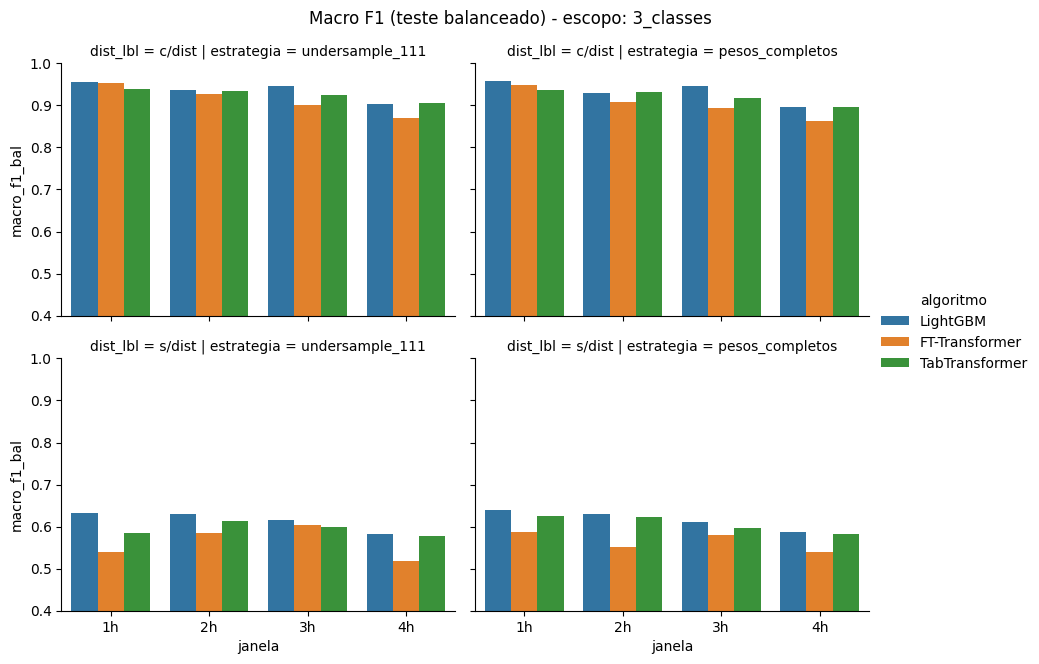

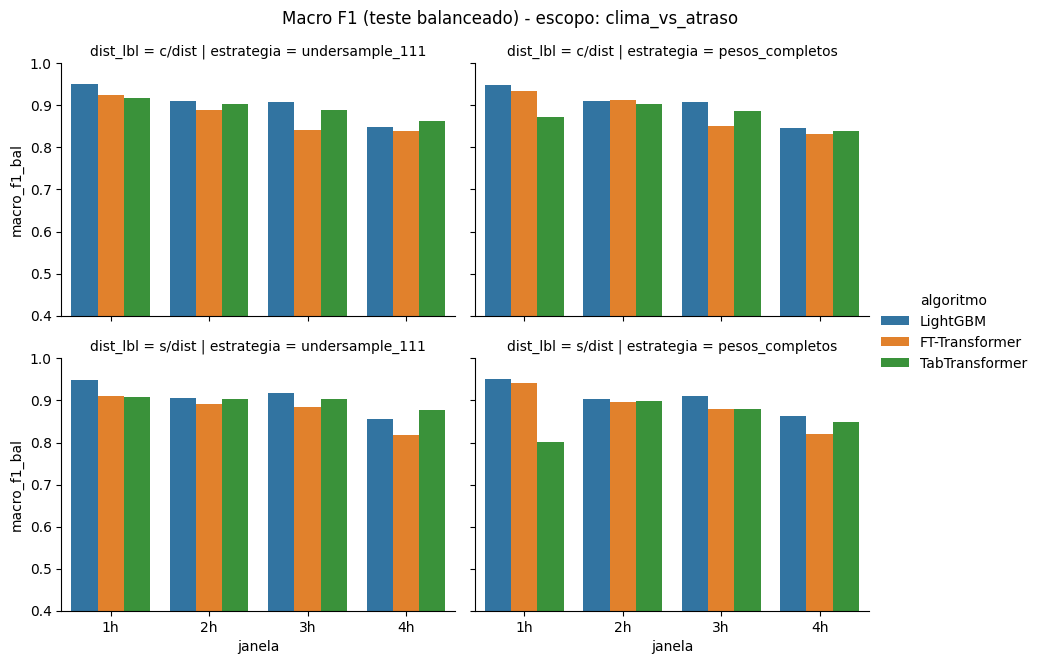

In [10]:
df_r = df_resultados.copy()
df_r['dist_lbl'] = df_r['dist_aeroporto'].map({True: 'c/dist', False: 's/dist'})
print('RANKING COMPLETO (por macro_f1_bal):')
display(df_r.sort_values('macro_f1_bal', ascending=False).reset_index(drop=True))

# Barras facetadas por escopo: janela x algoritmo, colunas = estrategia, linhas = distancia
for escopo in ESCOPOS:
    sub = df_r[df_r['escopo'] == escopo]
    if sub.empty:
        continue
    g = sns.catplot(data=sub, kind='bar', x='janela', y='macro_f1_bal', hue='algoritmo',
                    col='estrategia', row='dist_lbl', order=JANELAS,
                    height=3.2, aspect=1.4, legend_out=True)
    g.set(ylim=(0.4, 1.0))
    g.fig.suptitle(f'Macro F1 (teste balanceado) - escopo: {escopo}', y=1.03)
    plt.show()

In [11]:
# Melhor cenario por escopo
print('MELHOR CENARIO POR ESCOPO (macro_f1_bal):')
display(df_resultados.loc[df_resultados.groupby('escopo')['macro_f1_bal'].idxmax()].reset_index(drop=True))

# Melhor por escopo x algoritmo
print('\nMELHOR POR ESCOPO x ALGORITMO:')
idx2 = df_resultados.groupby(['escopo', 'algoritmo'])['macro_f1_bal'].idxmax()
display(df_resultados.loc[idx2].sort_values(['escopo', 'macro_f1_bal'], ascending=[True, False]).reset_index(drop=True))

# Efeito da ESTRATEGIA de balanceamento
print('\nEFEITO DA ESTRATEGIA (media macro_f1_bal):')
display(df_resultados.groupby(['escopo', 'estrategia'])['macro_f1_bal'].mean().unstack())

# Efeito da DISTANCIA
print('\nEFEITO DA DISTANCIA (media macro_f1_bal):')
display(df_resultados.groupby(['escopo', 'dist_aeroporto'])['macro_f1_bal'].mean().unstack()
        .rename(columns={True: 'Com Dist', False: 'Sem Dist'}))

# Honestidade: gap entre teste balanceado e natural
print('\nGAP balanceado vs natural (media) -- quanto o balanceado superestima:')
g = df_resultados.groupby(['escopo', 'estrategia'])[['macro_f1_bal', 'macro_f1_nat']].mean()
g['gap'] = g['macro_f1_bal'] - g['macro_f1_nat']
display(g)

melhor = df_resultados.loc[df_resultados['macro_f1_bal'].idxmax()]
print('\n' + '=' * 60)
print('MELHOR CENARIO GERAL')
print('=' * 60)
for k in ['escopo', 'estrategia', 'algoritmo', 'janela', 'dist_aeroporto', 'macro_f1_bal', 'macro_f1_nat']:
    print(f'  {k:15s}: {melhor[k]}')

MELHOR CENARIO POR ESCOPO (macro_f1_bal):


,escopo,estrategia,algoritmo,janela,dist_aeroporto,macro_f1_bal,macro_f1_nat,acc_bal,acc_nat,f1_nao_evento,f1_clima,f1_atraso,exp_id
0,3_classes,pesos_completos,LightGBM,1h,True,0.9587,0.9594,0.9590,0.9603,0.9799,0.9566,0.9397,7
1,clima_vs_atraso,pesos_completos,LightGBM,1h,False,0.9522,0.9524,0.9522,0.9524,NaN,0.9523,0.9520,22



MELHOR POR ESCOPO x ALGORITMO:


,escopo,estrategia,algoritmo,janela,dist_aeroporto,macro_f1_bal,macro_f1_nat,acc_bal,acc_nat,f1_nao_evento,f1_clima,f1_atraso,exp_id
0,3_classes,pesos_completos,LightGBM,1h,True,0.9587,0.9594,0.9590,0.9603,0.9799,0.9566,0.9397,7
1,3_classes,undersample_111,FT-Transformer,1h,True,0.9525,0.9524,0.9525,0.9530,0.9935,0.9328,0.9313,2
2,3_classes,undersample_111,TabTransformer,1h,True,0.9394,0.9387,0.9392,0.9393,0.9751,0.9259,0.9171,3
3,clima_vs_atraso,pesos_completos,LightGBM,1h,False,0.9522,0.9524,0.9522,0.9524,NaN,0.9523,0.9520,22
4,clima_vs_atraso,pesos_completos,FT-Transformer,1h,False,0.9412,0.9412,0.9413,0.9413,NaN,0.9402,0.9423,23
5,clima_vs_atraso,undersample_111,TabTransformer,1h,True,0.9179,0.9169,0.9181,0.9169,NaN,0.9146,0.9213,15



EFEITO DA ESTRATEGIA (media macro_f1_bal):


...


EFEITO DA DISTANCIA (media macro_f1_bal):


dist_aeroporto,Sem Dist,Com Dist
escopo,,
3_classes,0.593079,0.921700
clima_vs_atraso,0.888308,0.888787



GAP balanceado vs natural (media) -- quanto o balanceado superestima:


macro_f1_bal  macro_f1_nat       gap
escopo          estrategia                                           
3_classes       pesos_completos      0.757337      0.756158  0.001179
                undersample_111      0.757442      0.756179  0.001263
clima_vs_atraso pesos_completos      0.884854      0.884725  0.000129
                undersample_111      0.892242      0.892117  0.000125


MELHOR CENARIO GERAL
  escopo         : 3_classes
  estrategia     : pesos_completos
  algoritmo      : LightGBM
  janela         : 1h
  dist_aeroporto : True
  macro_f1_bal   : 0.9587
  macro_f1_nat   : 0.9594


## 10. Explicabilidade (XAI) do Melhor Cenário

Retreina o melhor cenário geral (por `macro_f1_bal`) e roda a XAI apropriada: **SHAP** (LightGBM) ou **importância por permutação** (transformers), além da matriz de confusão no teste natural. Para explicar outro cenário, edite `alvo`.

XAI para: 3_classes | pesos_completos | LightGBM | janela 1h | dist True


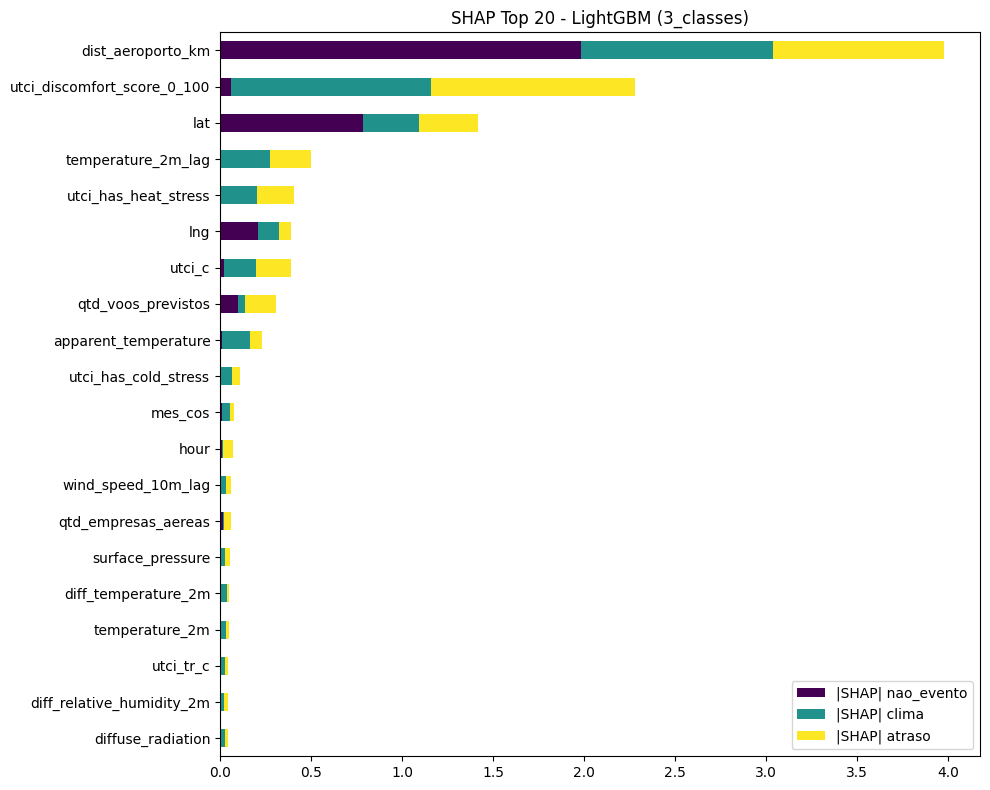

,|SHAP| nao_evento,|SHAP| clima,|SHAP| atraso,Total
dist_aeroporto_km,1.985066,1.053090,0.937916,3.976072
utci_discomfort_score_0_100,0.062126,1.094063,1.120844,2.277034
lat,0.784281,0.310351,0.320753,1.415384
temperature_2m_lag,0.007109,0.268117,0.225759,0.500985
utci_has_heat_stress,0.003989,0.200699,0.203551,0.408239
lng,0.207383,0.114257,0.067976,0.389615
utci_c,0.023451,0.175106,0.189836,0.388393
qtd_voos_previstos,0.098523,0.036360,0.171104,0.305988
apparent_temperature,0.007756,0.155754,0.066499,0.230009
utci_has_cold_stress,0.000180,0.066474,0.042015,0.108669


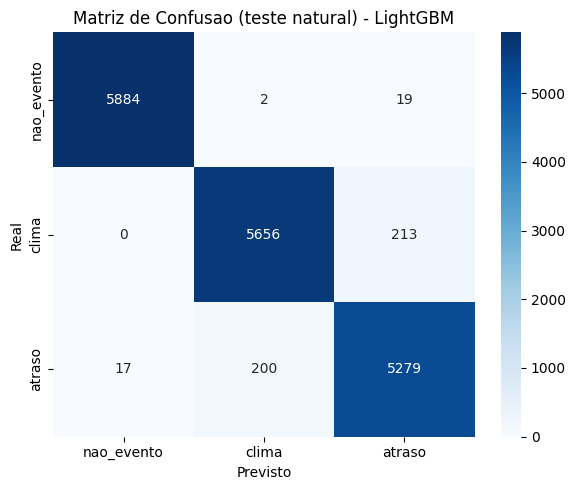

In [12]:
alvo = df_resultados.loc[df_resultados['macro_f1_bal'].idxmax()].to_dict()
print('XAI para:', alvo['escopo'], '|', alvo['estrategia'], '|', alvo['algoritmo'],
      '| janela', alvo['janela'], '| dist', alvo['dist_aeroporto'])

dfm_alvo = construir_base_master(alvo['janela'])
dados = preparar_dados(dfm_alvo, bool(alvo['dist_aeroporto']), alvo['escopo'], alvo['estrategia'])
inv = {v: k for k, v in dados['classe_por_nome'].items()}
labels = [inv[i] for i in range(dados['n_classes'])]

if alvo['algoritmo'] == 'LightGBM':
    r = treinar_lightgbm(dados, LGBM_OPTUNA_TRIALS)
    model = r['_model']; feats = dados['lgbm']['features']; X_te = dados['lgbm']['X_te_nat']
    Xs = X_te.sample(n=min(5000, len(X_te)), random_state=RANDOM_STATE).reset_index(drop=True)
    raw = shap.TreeExplainer(model).shap_values(Xs)
    if isinstance(raw, list):
        svc = raw
    elif getattr(raw, 'ndim', 2) == 3:
        svc = [raw[:, :, i] for i in range(raw.shape[2])]
    else:
        svc = [raw]
    cols = [f'|SHAP| {labels[i]}' for i in range(len(svc))]
    mean_abs = np.array([np.abs(s).mean(axis=0) for s in svc])
    imp = pd.DataFrame(mean_abs.T, index=feats, columns=cols)
    imp['Total'] = imp.sum(axis=1); imp = imp.sort_values('Total', ascending=False)
    imp.head(20)[cols].iloc[::-1].plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')
    plt.title(f"SHAP Top 20 - {alvo['algoritmo']} ({alvo['escopo']})"); plt.tight_layout(); plt.show()
    display(imp.head(20))
else:
    build = build_ft if alvo['algoritmo'] == 'FT-Transformer' else build_tab
    r = treinar_transformer(build, alvo['algoritmo'], dados)
    imp = importancia_permutacao(r['_model'], dados)
    top = imp.head(20).iloc[::-1]
    plt.figure(figsize=(10, 8)); plt.barh(top['feature'], top['importancia'], color='#2b8cbe')
    plt.title(f"Permutacao Top 20 - {alvo['algoritmo']} ({alvo['escopo']})")
    plt.xlabel('Queda no Macro-F1'); plt.tight_layout(); plt.show()
    display(imp.head(20))

cm = confusion_matrix(r['_y_true_nat'], r['_y_pred_nat'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"Matriz de Confusao (teste natural) - {alvo['algoritmo']}")
plt.ylabel('Real'); plt.xlabel('Previsto'); plt.tight_layout(); plt.show()

## 11.1 Salvar Melhor Modelo no Drive

Persiste o LightGBM retreinado acima + metadados (features, classes, métricas) para uso no pipeline de narração em linguagem natural (`05_5_Narrador_Natural.ipynb`).

In [ ]:
import joblib, json, os

MODEL_PATH = '/content/drive/MyDrive/DOUTORADO/melhor_modelo_lgbm.joblib'
META_PATH  = '/content/drive/MyDrive/DOUTORADO/melhor_modelo_meta.json'

joblib.dump(r['_model'], MODEL_PATH)
print(f'Modelo salvo: {MODEL_PATH}')

meta = {
    'algoritmo':      alvo['algoritmo'],
    'escopo':         alvo['escopo'],
    'estrategia':     alvo['estrategia'],
    'janela':         alvo['janela'],
    'dist_aeroporto': bool(alvo['dist_aeroporto']),
    'features_lgbm':  dados['lgbm']['features'],
    'cont_features':  dados['cont'],
    'classe_por_nome': dados['classe_por_nome'],
    'macro_f1_bal':   float(alvo['macro_f1_bal']),
    'macro_f1_nat':   float(alvo['macro_f1_nat']),
}
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f'Metadados salvos: {META_PATH}')
print()
for k, v in meta.items():
    if k not in ('features_lgbm', 'cont_features'):
        print(f'  {k}: {v}')

## 11. Conclusões

Como ler os resultados:

- **Melhor algoritmo/cenário:** ranking por `macro_f1_bal` (célula 9). Compare também `macro_f1_nat` — o **gap** entre os dois mede o quanto a métrica balanceada superestima o desempenho real (onde a classe 0 domina).
- **Escopo `clima_vs_atraso`:** é aqui que se vê a real capacidade de separar os dois eventos causalmente ligados, sem a classe fácil inflando a métrica. Se o F1 binário for baixo, confirma que a fronteira clima×atraso é intrinsecamente difícil (problema de features, não de balanceamento).
- **Estratégia de balanceamento:** a tabela "efeito da estratégia" mostra se `pesos_completos` (manter os dados) supera `undersample_111` (descartar). Ganho consistente = o undersampling estava jogando fora sinal útil.
- **Distância ao aeroporto:** "efeito da distância" quantifica o ganho do sinal espacial — relevante especialmente no escopo binário.

**Ressalvas metodológicas (para a tese):**
- Split temporal primeiro; balanceamento apenas no treino; teste sempre natural. Isso corrige o vazamento de balanceamento para a avaliação que existia quando o undersampling era global.
- Os três modelos compartilham features, split e recipe de pesos — a comparação isola o algoritmo. Capacidade fixa (sem busca exaustiva de arquitetura); resultados refletem configurações razoáveis, não ótimos globais.
- Rebalancear muda prioris, não separabilidade: para melhorar de fato o clima×atraso, o caminho é **feature engineering de defasagem temporal** (múltiplos lags do clima que precede o atraso) — um próximo passo natural a partir deste notebook.
- Execução em Google Colab; grid completo pode levar horas. Resultados parciais são salvos em `CSV_OUT` a cada experimento.